#1.Replacing the NaN values

In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("Placement.csv")

In [3]:
dataset.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [4]:
quan=[]
qual=[]
for columnName in dataset.columns:
    if(dataset[columnName].dtype=='str'):
        qual.append(columnName)
    else:
        quan.append(columnName)

In [5]:
print(quan)

['sl_no', 'ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']


In [6]:
for columnName in quan:
    dataset[columnName]=dataset[columnName].fillna(0)

In [7]:
dataset.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

In [8]:
# Since the NaN values are present in salary we can't take mean or median
# So i have filled it with zero.

#2.How many are not placed

In [9]:
not_placed= dataset[dataset["status"]=="Not Placed"]
print(len(not_placed))

67


#3.Reason for non placement

In [10]:
not_placed.describe()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.0
mean,110.477612,57.544030,58.395522,61.134179,69.587910,61.612836,0.0
std,65.859667,8.394246,9.914090,6.365825,11.930687,5.705689,0.0
min,4.000000,40.890000,37.000000,50.000000,50.000000,51.210000,0.0
25%,48.500000,52.000000,51.000000,57.000000,60.000000,58.480000,0.0
50%,107.000000,56.280000,60.330000,61.000000,67.000000,60.690000,0.0
75%,170.500000,63.000000,64.000000,65.000000,76.500000,65.405000,0.0
max,215.000000,77.800000,82.000000,79.000000,97.000000,75.710000,0.0


In [11]:
# ON COMPARING THIS WITH PLACED STUDENTS REPORT WE CAN COME TO A SOLUTION

#4.Relation btn salary and mba_p

In [12]:
corr=dataset["salary"].corr(dataset["mba_p"])
print(corr)

0.1398227389261557


In [13]:
# Since it is greater than zero but at a very minimal value there is no positive relation with salary and mba_p

#5.Specialization of minimum salary

In [14]:
dataset.groupby("specialisation")["salary"].min()

specialisation
Mkt&Fin    0.0
Mkt&HR     0.0
Name: salary, dtype: float64

#6.Above 500000 salary

In [15]:
high_salary=dataset[dataset["salary"]>500000]
print(len(high_salary))

3


#7.ANOVA BTN etest_p and mba_p

In [16]:
import scipy.stats as stats
stats.f_oneway(dataset["etest_p"],dataset["mba_p"])

F_onewayResult(statistic=np.float64(98.64487057324708), pvalue=np.float64(4.672547689133693e-21))

In [17]:
# SINCE THE P-VALUE IS GREATER THAN 0.05% WE ACCEPT NULL HYPOTHESIS
# THERE IS NO SIGNIFICANT CHANGE IN ETEST_P AND MBA_P MARKS

#8 degree ,specialisation with salary

In [18]:
from scipy.stats import ttest_ind
degree=dataset[(dataset["degree_t"]=="Sci&Tech")]["salary"]
specialisation=dataset[(dataset["specialisation"]=="Mkt&HR")]["salary"]
stats.ttest_ind(degree,specialisation)

TtestResult(statistic=np.float64(2.692041243555374), pvalue=np.float64(0.007897969943471191), df=np.float64(152.0))

In [19]:
#Since the p-value<0.05% we reject Null hypothesis
#There is a significant change in degree and specialisation

#9 Salary to STD Normal distribution

In [20]:
from sklearn.preprocessing import StandardScaler
dataset["salary_original"]=dataset["salary"]
sc = StandardScaler()
dataset["salary_standard"]=sc.fit_transform(dataset[["salary"]])
dataset.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary,salary_original,salary_standard
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0,270000.0,0.461711
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0,200000.0,0.008404
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0,250000.0,0.332195
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0.0,0.0,-1.286761
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0,425000.0,1.465463


In [21]:
dataset["salary_standard"].mean().item()

-8.881784197001253e-17

In [22]:
dataset["salary_standard"].std().item()

1.0023337254608675

#10 PDF of 7000000 and 900000

In [23]:
import scipy.stats as stats
mean=dataset["salary_original"].mean()
std=dataset["salary_original"].std()
probability = stats.norm.cdf(900000,mean,std)-stats.norm.cdf(700000,mean,std)
print(probability)

0.0005973243061798694


#11 degree and etest_p, mba_p

In [24]:
from scipy.stats import ttest_rel
degree=dataset[(dataset["degree_t"]=="Sci&Tech")]["etest_p"]
degree1=dataset[(dataset["degree_t"]=="Sci&Tech")]["mba_p"]
stats.ttest_rel(degree,degree1)

TtestResult(statistic=np.float64(5.0049844583693615), pvalue=np.float64(5.5179206005054e-06), df=np.int64(58))

In [ ]:
#Since the p-value> 0.05% we accept the Null hypothesis
#THERE IS NO SIGNIFICANT CHANGE IN ETEST,MBA_P FOR DEGREE_T

#12 HIGHLY CORRELATED

In [28]:
dataset.corr(numeric_only=True)["salary"].sort_values(ascending=False)

salary_original    1.000000
salary             1.000000
salary_standard    1.000000
ssc_p              0.538090
hsc_p              0.452569
degree_p           0.408371
etest_p            0.186988
mba_p              0.139823
sl_no              0.002543
Name: salary, dtype: float64

In [29]:
#SALARY IS MORE CORRELATED WITH SSC_P MARKS

#13 GRAPH

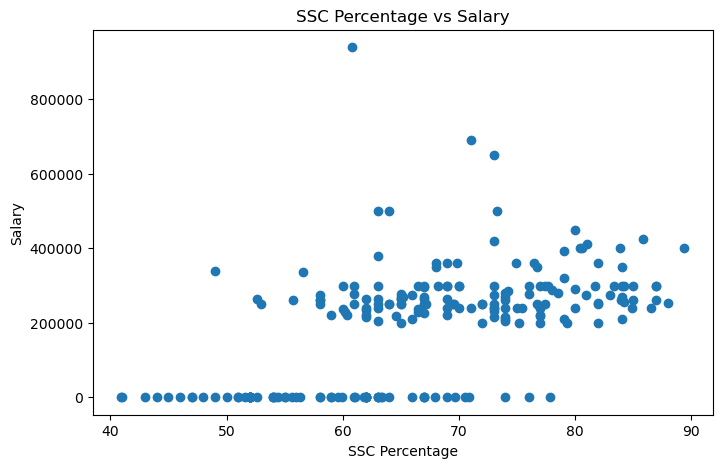

In [31]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(dataset["ssc_p"],dataset["salary"])
plt.xlabel("SSC Percentage")
plt.ylabel("Salary")
plt.title("SSC Percentage vs Salary")
plt.show()